In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv(r"10_employees_vs_revenue.csv")

print("First 5 rows:")
print(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nAttributes:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nSummary:")
print(df.describe(include="all"))

print("\ninformation")
print(df.info)

First 5 rows:
  num_employees marketing_spend_usd competitor_price_usd season_index  \
0            81               70.79                54.15            3   
1           177              313.39                46.67            2   
2            85              364.09                58.21          NaN   
3           182              394.15                 7.31            3   
4            30              411.92                 6.01            3   

   revenue_thousand_usd  
0                1278.0  
1                2204.0  
2                1392.0  
3                2203.0  
4                 362.0  

Shape of dataset:
(308, 5)

Attributes:
Index(['num_employees', 'marketing_spend_usd', 'competitor_price_usd',
       'season_index', 'revenue_thousand_usd'],
      dtype='object')

Data types:
num_employees            object
marketing_spend_usd      object
competitor_price_usd     object
season_index             object
revenue_thousand_usd    float64
dtype: object

Summary:
       num_e

In [2]:
print("\nmissing values")
print(df.isnull().sum())

print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("\n outliers")

for col in ["num_employees", "marketing_spend_usd",
            "competitor_price_usd", "season_index",
            "revenue_thousand_usd"]:

    df[col] = pd.to_numeric(df[col], errors="coerce")

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

print("Outliers handled using IQR method.")


missing values
num_employees            6
marketing_spend_usd      5
competitor_price_usd     6
season_index            14
revenue_thousand_usd     4
dtype: int64
8

 outliers
Outliers handled using IQR method.


In [3]:
cat_cols = df.select_dtypes(include=['object']).columns

print("categorical attributes:")
print(cat_cols)

df[cat_cols] = df[cat_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

print(df.head())

categorical attributes:
Index([], dtype='object')
   num_employees  marketing_spend_usd  competitor_price_usd  season_index  \
0           81.0                70.79                 54.15           3.0   
1          177.0               313.39                 46.67           2.0   
2           85.0               364.09                 58.21           NaN   
3          182.0               394.15                  7.31           3.0   
4           30.0               411.92                  6.01           3.0   

   revenue_thousand_usd  
0                1278.0  
1                2204.0  
2                1392.0  
3                2203.0  
4                 362.0  


In [4]:
numerical_columns = [
    "num_employees",
    "marketing_spend_usd",
    "competitor_price_usd",
    "season_index",
    "revenue_thousand_usd"
]

print("Numerical attributes:")
print(numerical_columns)

# Handle missing values
for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

# Standardization
scaler = StandardScaler()

df[numerical_columns] = scaler.fit_transform(
    df[numerical_columns]
)

print("\nScaled data:")
print(df[numerical_columns].head())

Numerical attributes:
['num_employees', 'marketing_spend_usd', 'competitor_price_usd', 'season_index', 'revenue_thousand_usd']

Scaled data:
   num_employees  marketing_spend_usd  competitor_price_usd  season_index  \
0      -0.400915            -1.193679              1.351195      0.443323   
1       1.187740             0.424253              0.916279     -0.362718   
2      -0.334721             0.762378              1.587260     -0.362718   
3       1.270482             0.962852             -1.372267      0.443323   
4      -1.244887             1.081363             -1.447854      0.443323   

   revenue_thousand_usd  
0             -0.007561  
1              1.319326  
2              0.155792  
3              1.317894  
4             -1.320119  


Correlation with revenue:
revenue_thousand_usd    1.000000
num_employees           0.837165
competitor_price_usd    0.117421
marketing_spend_usd     0.109590
season_index            0.042512
Name: revenue_thousand_usd, dtype: float64


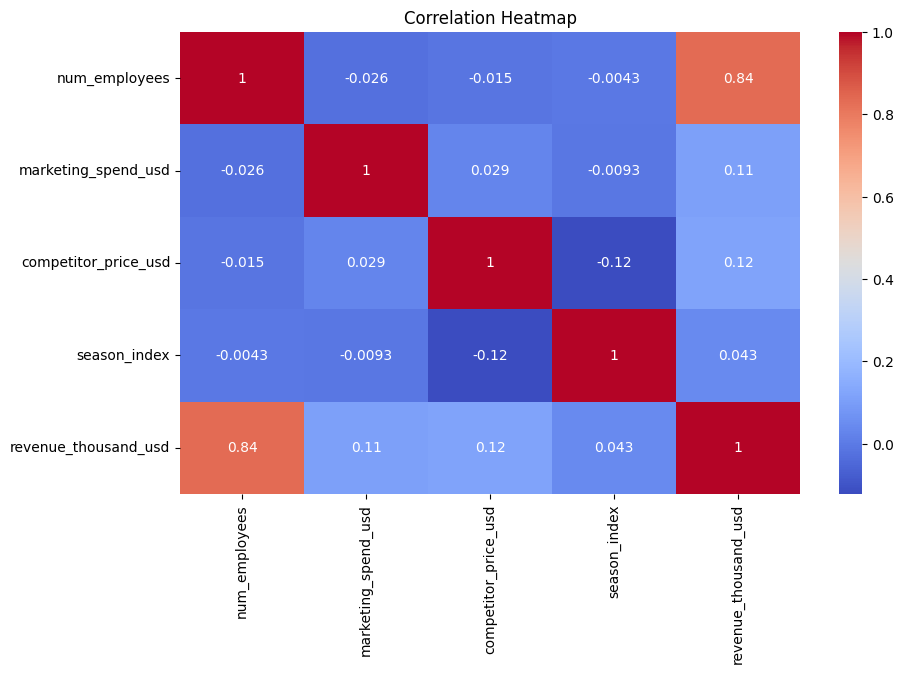


Correlation between Employees and Revenue:
0.8371646010275862


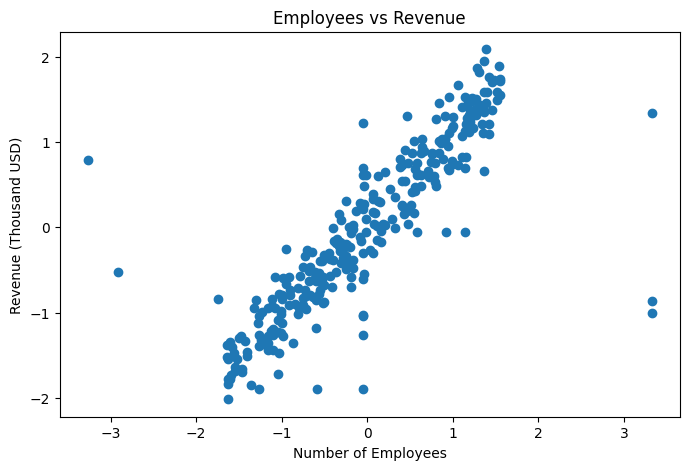

In [5]:
print("Correlation with revenue:")

print(
    df.select_dtypes(include="number")
      .corr()["revenue_thousand_usd"]
      .sort_values(ascending=False)
)

# Correlation heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# Relationship between employees and revenue
print("\nCorrelation between Employees and Revenue:")
print(
    df["num_employees"].corr(
        df["revenue_thousand_usd"]
    )
)

plt.figure(figsize=(8, 5))

plt.scatter(
    df["num_employees"],
    df["revenue_thousand_usd"]
)

plt.xlabel("Number of Employees")
plt.ylabel("Revenue (Thousand USD)")
plt.title("Employees vs Revenue")
plt.show()

In [6]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# Load dataset
df = pd.read_csv(r"10_employees_vs_revenue.csv")

# Remove extra spaces from column names, if any
df.columns = df.columns.str.strip()

print("Columns:")
print(df.columns.tolist())

# Convert columns to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Target
y = df["revenue_thousand_usd"]

# BEFORE FEATURE SELECTION
features_before = [
    "num_employees",
    "marketing_spend_usd",
    "competitor_price_usd",
    "season_index"
]

X_before = df[features_before]

print("\nFeatures before selection:")
print(X_before.columns.tolist())

# Numerical features
numeric_features = [
    "num_employees",
    "marketing_spend_usd",
    "competitor_price_usd",
    "season_index"
]

# Handle missing values
imputer = SimpleImputer(strategy="median")

X_before = pd.DataFrame(
    imputer.fit_transform(X_before),
    columns=numeric_features
)

# Standardization
scaler = StandardScaler()

X_before = pd.DataFrame(
    scaler.fit_transform(X_before),
    columns=numeric_features
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_before,
    y,
    test_size=0.2,
    random_state=42
)

# Handle missing target values
train_valid = y_train.notna()
test_valid = y_test.notna()

X_train = X_train.loc[train_valid]
y_train = y_train.loc[train_valid]

X_test = X_test.loc[test_valid]
y_test = y_test.loc[test_valid]

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Performance
mse_before = mean_squared_error(y_test, y_pred)
r2_before = r2_score(y_test, y_pred)

print("\nMean Squared Error BEFORE feature selection:", mse_before)
print("R2 Score BEFORE feature selection:", r2_before)


# AFTER FEATURE SELECTION

selected_features = [
    "num_employees",
    "marketing_spend_usd"
]

X_after = df[selected_features]

print("\nSelected features:")
print(X_after.columns.tolist())

# Handle missing values
imputer_selected = SimpleImputer(strategy="median")

X_after = pd.DataFrame(
    imputer_selected.fit_transform(X_after),
    columns=selected_features
)

# Standardization
scaler_selected = StandardScaler()

X_after = pd.DataFrame(
    scaler_selected.fit_transform(X_after),
    columns=selected_features
)

# Split data
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_after,
    y,
    test_size=0.2,
    random_state=42
)

# Handle missing target values
train_valid2 = y_train2.notna()
test_valid2 = y_test2.notna()

X_train2 = X_train2.loc[train_valid2]
y_train2 = y_train2.loc[train_valid2]

X_test2 = X_test2.loc[test_valid2]
y_test2 = y_test2.loc[test_valid2]

# Train
model_selected = LinearRegression()
model_selected.fit(X_train2, y_train2)

# Predict
y_pred2 = model_selected.predict(X_test2)

# Performance
mse_after = mean_squared_error(y_test2, y_pred2)
r2_after = r2_score(y_test2, y_pred2)

print("\nMean Squared Error AFTER feature selection:", mse_after)
print("R2 Score AFTER feature selection:", r2_after)


# COMPARISON
print("\n--- Model Performance Comparison ---")
print("Before Feature Selection - R2 Score:", r2_before)
print("After Feature Selection - R2 Score:", r2_after)

Columns:
['num_employees', 'marketing_spend_usd', 'competitor_price_usd', 'season_index', 'revenue_thousand_usd']

Features before selection:
['num_employees', 'marketing_spend_usd', 'competitor_price_usd', 'season_index']

Mean Squared Error BEFORE feature selection: 542152.448591592
R2 Score BEFORE feature selection: 0.015696445853793706

Selected features:
['num_employees', 'marketing_spend_usd']

Mean Squared Error AFTER feature selection: 541747.972253509
R2 Score AFTER feature selection: 0.01643079188170049

--- Model Performance Comparison ---
Before Feature Selection - R2 Score: 0.015696445853793706
After Feature Selection - R2 Score: 0.01643079188170049
